# 03. XGBoost Gradient Boosting History Sweep (h=0..10) — 200 Users

This notebook evaluates **XGBoost Gradient Boosted Decision Trees** across a comprehensive sweep of history depths:
$$\mathbf{h \in [0, 1, 2, 3, 4, 5, 7, 10]}$$

### Experimental Setup:
- **Model:** `MultiOutputRegressor(XGBRegressor(n_estimators=250, max_depth=8, learning_rate=0.15, subsample=0.8, colsample_bytree=0.8))`.
- **Feature Mode:** Absolute Lags Set.
- **Data Partitioning:** Unseen User Split (160 Training Users / 40 Unseen Test Users).
- **Kinematic Post-Processing:** Raw XGBoost vs. Forward Linear KF vs. RTS Kalman Smoother.

In [1]:
import sys, os, time, warnings, json, math, datetime, glob
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
from scipy.linalg import inv

NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(10):
    if (PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25').exists():
        break
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'experiments' / '09_grid_localization' / 'src' / 'python'))

from pipelines.multi_user_200_pipeline import load_200_users, make_unseen_user_split
from pipelines.multi_user_pipeline_regression import _read_bs_position_3d, build_history_features, get_feature_cols

RUN_TIMESTAMP = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
OUT_DIR = PROJECT_ROOT / 'results' / 'notebook_experiments' / 'multi_user_poc' / f'xgb_history_sweep_{RUN_TIMESTAMP}'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {OUT_DIR}')

Output directory: D:\gilad\projects\Academy\CSI-Location\results\notebook_experiments\multi_user_poc\xgb_history_sweep_2026-07-24_20-18-34


## Define Kinematic Kalman Filter & RTS Backward Smoother

In [2]:
def run_kalman_and_rts(y_true, y_pred, delta_t_vec, process_noise_std=0.5, R_std=15.0):
    N = len(y_pred)
    if N == 0:
        return y_pred, y_pred
    
    H = np.zeros((3, 6))
    H[0, 0], H[1, 1], H[2, 2] = 1.0, 1.0, 1.0
    R = (R_std ** 2) * np.eye(3)
    
    x_pred = np.zeros((N, 6)); P_pred = np.zeros((N, 6, 6))
    x_filt = np.zeros((N, 6)); P_filt = np.zeros((N, 6, 6))
    
    x_filt[0, :3] = y_pred[0]
    P_filt[0] = np.eye(6) * 100.0
    x_pred[0], P_pred[0] = x_filt[0], P_filt[0]
    
    for t in range(1, N):
        dt = max(0.01, float(delta_t_vec[t]))
        F = np.eye(6); F[0, 3], F[1, 4], F[2, 5] = dt, dt, dt
        q = (process_noise_std ** 2)
        Q = np.diag([q*(dt**2), q*(dt**2), q*(dt**2), q, q, q])
        
        x_p = F @ x_filt[t-1]
        P_p = F @ P_filt[t-1] @ F.T + Q
        x_pred[t], P_pred[t] = x_p, P_p
        
        z_t = y_pred[t]
        y_k = z_t - H @ x_p
        S_k = H @ P_p @ H.T + R
        K_k = P_p @ H.T @ inv(S_k)
        
        x_filt[t] = x_p + K_k @ y_k
        P_filt[t] = (np.eye(6) - K_k @ H) @ P_p
        
    x_smooth = np.zeros((N, 6)); P_smooth = np.zeros((N, 6, 6))
    x_smooth[-1], P_smooth[-1] = x_filt[-1], P_filt[-1]
    
    for t in range(N - 2, -1, -1):
        dt = max(0.01, float(delta_t_vec[t+1]))
        F = np.eye(6); F[0, 3], F[1, 4], F[2, 5] = dt, dt, dt
        C_k = P_filt[t] @ F.T @ inv(P_pred[t+1])
        x_smooth[t] = x_filt[t] + C_k @ (x_smooth[t+1] - x_pred[t+1])
        P_smooth[t] = P_filt[t] + C_k @ (P_smooth[t+1] - P_pred[t+1]) @ C_k.T
        
    return x_filt[:, :3], x_smooth[:, :3]

## Load 200-User Dataset & Apply Noise Model

In [3]:
data_base = PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25'
dirs = sorted(list(data_base.glob('sim_data_200users_*')))
if not dirs:
    raise FileNotFoundError('No sim_data_200users_* dataset directories found!')
DATA_DIR = dirs[-1]
print(f'Loading 200-User dataset from: {DATA_DIR}')

df_raw = load_200_users(DATA_DIR)
print(f'Loaded {len(df_raw):,} records across {len(df_raw["user_id"].unique())} diverse mobile users.')

bs_pos = np.array(_read_bs_position_3d(DATA_DIR))
ue_xyz = np.column_stack([df_raw['x_pos'], df_raw['y_pos'], df_raw['ue_height']])
delta  = ue_xyz - bs_pos
df_raw['target_x'], df_raw['target_y'], df_raw['target_z'] = delta[:,0], delta[:,1], delta[:,2]

SEED = 42
AOA_NOISE_STD_DEG = 4.0
AOA_QUANT_STEP_DEG = 5.0
mask_ant = df_raw['n_antennas'] > 1
rng_noise = np.random.RandomState(SEED)
df_raw.loc[mask_ant, 'aoa_azimuth'] = df_raw.loc[mask_ant, 'aoa_azimuth'].values + (AOA_NOISE_STD_DEG * rng_noise.randn(mask_ant.sum())).astype(np.float32)
df_raw.loc[mask_ant, 'aoa_elevation'] = df_raw.loc[mask_ant, 'aoa_elevation'].values + (AOA_NOISE_STD_DEG * rng_noise.randn(mask_ant.sum())).astype(np.float32)
df_raw.loc[mask_ant, 'aoa_azimuth'] = np.round(df_raw.loc[mask_ant, 'aoa_azimuth'] / AOA_QUANT_STEP_DEG) * AOA_QUANT_STEP_DEG
df_raw.loc[mask_ant, 'aoa_elevation'] = np.round(df_raw.loc[mask_ant, 'aoa_elevation'] / AOA_QUANT_STEP_DEG) * AOA_QUANT_STEP_DEG
df_raw.loc[~mask_ant, ['aoa_azimuth', 'aoa_elevation']] = 0.0
print('Noise model applied.')

Loading 200-User dataset from: D:\gilad\projects\Academy\CSI-Location\results\grid_localization\grid_25x25\sim_data_200users_2026-07-24_18-09-51


Loaded 99,589 records across 200 diverse mobile users.
Noise model applied.


## Execute XGBoost History Depth Sweep (h=0, 1, 2, 3, 4, 5, 7, 10)

In [4]:
H_LIST = [0, 1, 2, 3, 4, 5, 7, 10]
FEATURE_MODE = 'absolute'
N_JOBS = 4
results = []
sample_user_trajectories = {}

print('Starting XGBoost History Depth Sweep across h=0..10...')
print('='*75)

for h in H_LIST:
    df_feat = build_history_features(df_raw, h=h, extra_cols=['device'], include_aoa=True, feature_mode=FEATURE_MODE)
    feat_cols = get_feature_cols(h=h, extra_cols=['device'], include_aoa=True, feature_mode=FEATURE_MODE)
    target_cols = ['target_x', 'target_y', 'target_z']
    df_feat[feat_cols] = df_feat[feat_cols].fillna(0.0)
    
    df_split, train_users, test_users = make_unseen_user_split(df_feat, train_ratio=0.80, seed=SEED)
    df_train = df_split[df_split['split']=='train'].reset_index(drop=True)
    df_test  = df_split[df_split['split']=='test'].reset_index(drop=True)
    
    X_tr, y_tr = df_train[feat_cols].values, df_train[target_cols].values
    X_te, y_te = df_test[feat_cols].values, df_test[target_cols].values
    
    t0 = time.time()
    base_xgb = XGBRegressor(n_estimators=250, max_depth=8, learning_rate=0.15, subsample=0.8, colsample_bytree=0.8, n_jobs=N_JOBS, random_state=SEED)
    xgb_model = MultiOutputRegressor(base_xgb)
    xgb_model.fit(X_tr, y_tr)
    t_fit = time.time() - t0
    
    preds_raw = xgb_model.predict(X_te)
    df_test['pred_x'] = preds_raw[:, 0]
    df_test['pred_y'] = preds_raw[:, 1]
    df_test['pred_z'] = preds_raw[:, 2]
    
    raw_err = np.linalg.norm(preds_raw - y_te, axis=1)
    mae_raw = np.mean(raw_err)
    
    kf_preds = np.zeros_like(preds_raw)
    rts_preds = np.zeros_like(preds_raw)
    
    for uid in test_users:
        idx_u = df_test['user_id'] == uid
        udf = df_test[idx_u].sort_values('step_index')
        u_indices = udf.index.values
        
        y_u_true = udf[target_cols].values
        y_u_pred = udf[['pred_x', 'pred_y', 'pred_z']].values
        dt_u     = udf['delta_t'].values
        
        x_kf, x_rts = run_kalman_and_rts(y_u_true, y_u_pred, dt_u, process_noise_std=0.5, R_std=15.0)
        kf_preds[u_indices]  = x_kf
        rts_preds[u_indices] = x_rts
        
    mae_kf  = np.mean(np.linalg.norm(kf_preds - y_te, axis=1))
    mae_rts = np.mean(np.linalg.norm(rts_preds - y_te, axis=1))
    red_rts = ((mae_raw - mae_rts) / mae_raw) * 100.0
    
    if h == 10:
        target_uid = sorted(list(test_users))[0]
        idx_target = df_test['user_id'] == target_uid
        udf_target = df_test[idx_target].sort_values('step_index')
        u_t_indices = udf_target.index.values
        sample_user_trajectories = {
            'uid': target_uid,
            'gt': udf_target[target_cols].values,
            'raw': preds_raw[u_t_indices],
            'rts': rts_preds[u_t_indices]
        }
    
    results.append({
        'h': h,
        'features': len(feat_cols),
        'fit_time_s': t_fit,
        'mae_raw': mae_raw,
        'mae_kf': mae_kf,
        'mae_rts': mae_rts,
        'red_rts_pct': red_rts
    })
    
    print(f'  h={h:2d} ({len(feat_cols):2d} feats) -> Raw XGB: {mae_raw:6.3f}m | Forward KF: {mae_kf:6.3f}m | RTS Smoother: {mae_rts:6.3f}m ({red_rts:+5.1f}%) | Time: {t_fit:4.1f}s')

Starting XGBoost History Depth Sweep across h=0..10...


  h= 0 ( 7 feats) -> Raw XGB: 28.325m | Forward KF: 27.487m | RTS Smoother: 27.294m ( +3.6%) | Time:  3.3s


  h= 1 (11 feats) -> Raw XGB: 26.930m | Forward KF: 27.251m | RTS Smoother: 26.345m ( +2.2%) | Time:  4.2s


  h= 2 (15 feats) -> Raw XGB: 25.823m | Forward KF: 26.626m | RTS Smoother: 25.392m ( +1.7%) | Time:  4.6s


  h= 3 (19 feats) -> Raw XGB: 25.907m | Forward KF: 27.105m | RTS Smoother: 25.724m ( +0.7%) | Time:  6.3s


  h= 4 (23 feats) -> Raw XGB: 25.761m | Forward KF: 27.128m | RTS Smoother: 25.658m ( +0.4%) | Time:  6.9s


  h= 5 (27 feats) -> Raw XGB: 25.404m | Forward KF: 26.946m | RTS Smoother: 25.381m ( +0.1%) | Time: 10.8s


  h= 7 (35 feats) -> Raw XGB: 25.229m | Forward KF: 27.114m | RTS Smoother: 25.180m ( +0.2%) | Time: 11.3s


  h=10 (47 feats) -> Raw XGB: 25.002m | Forward KF: 27.002m | RTS Smoother: 25.030m ( -0.1%) | Time: 13.2s


## Summary Benchmark Table (XGBoost h=0..10)

In [5]:
df_res = pd.DataFrame(results)
print('\n' + '='*85)
print('=== XGBOOST HISTORY SWEEP (h=0..10) & KALMAN SMOOTHING BENCHMARK ===')
print('='*85)
print(df_res.to_string(index=False, formatters={
    'h': lambda x: f'{x:2d}',
    'features': lambda x: f'{x:2d}',
    'fit_time_s': lambda x: f'{x:5.1f}s',
    'mae_raw': lambda x: f'{x:6.3f}m',
    'mae_kf': lambda x: f'{x:6.3f}m',
    'mae_rts': lambda x: f'{x:6.3f}m',
    'red_rts_pct': lambda x: f'{x:+5.1f}%'
}))
print('='*85)
df_res.to_csv(OUT_DIR / 'xgb_history_sweep_results.csv', index=False)


=== XGBOOST HISTORY SWEEP (h=0..10) & KALMAN SMOOTHING BENCHMARK ===
 h features fit_time_s mae_raw  mae_kf mae_rts red_rts_pct
 0        7       3.3s 28.325m 27.487m 27.294m       +3.6%
 1       11       4.2s 26.930m 27.251m 26.345m       +2.2%
 2       15       4.6s 25.823m 26.626m 25.392m       +1.7%
 3       19       6.3s 25.907m 27.105m 25.724m       +0.7%
 4       23       6.9s 25.761m 27.128m 25.658m       +0.4%
 5       27      10.8s 25.404m 26.946m 25.381m       +0.1%
 7       35      11.3s 25.229m 27.114m 25.180m       +0.2%
10       47      13.2s 25.002m 27.002m 25.030m       -0.1%


## Visualization: XGBoost 3D MAE vs. History Depth (h=0..10)

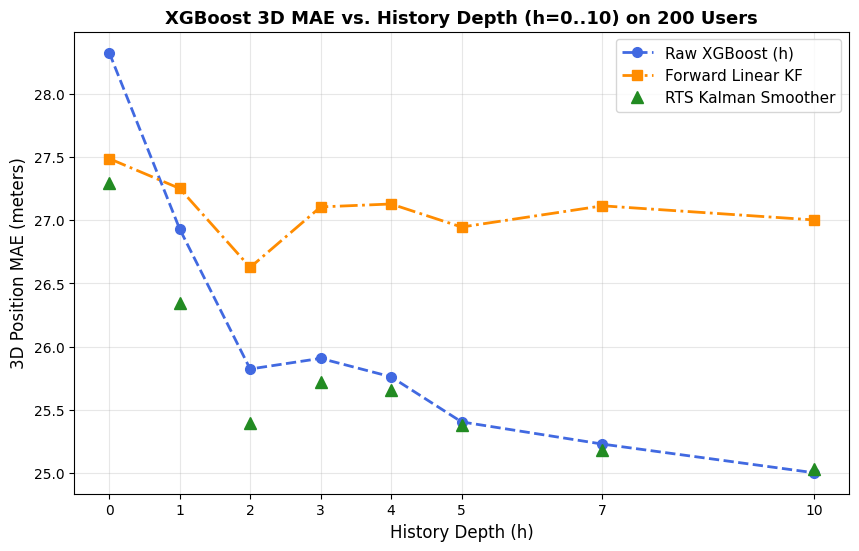

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(df_res['h'], df_res['mae_raw'], 'o--', color='royalblue', lw=2, ms=7, label='Raw XGBoost (h)')
plt.plot(df_res['h'], df_res['mae_kf'], 's-.', color='darkorange', lw=2, ms=7, label='Forward Linear KF')
plt.plot(df_res['h'], df_res['mae_rts'], '^', color='forestgreen', lw=2.5, ms=8, label='RTS Kalman Smoother')
plt.xlabel('History Depth (h)', fontsize=12)
plt.ylabel('3D Position MAE (meters)', fontsize=12)
plt.title('XGBoost 3D MAE vs. History Depth (h=0..10) on 200 Users', fontsize=13, fontweight='bold')
plt.xticks(H_LIST)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.savefig(OUT_DIR / 'xgb_history_sweep_mae.png', dpi=150, bbox_inches='tight')
plt.show()

## Trajectory Tracking Plot: Ground Truth vs. Predictions

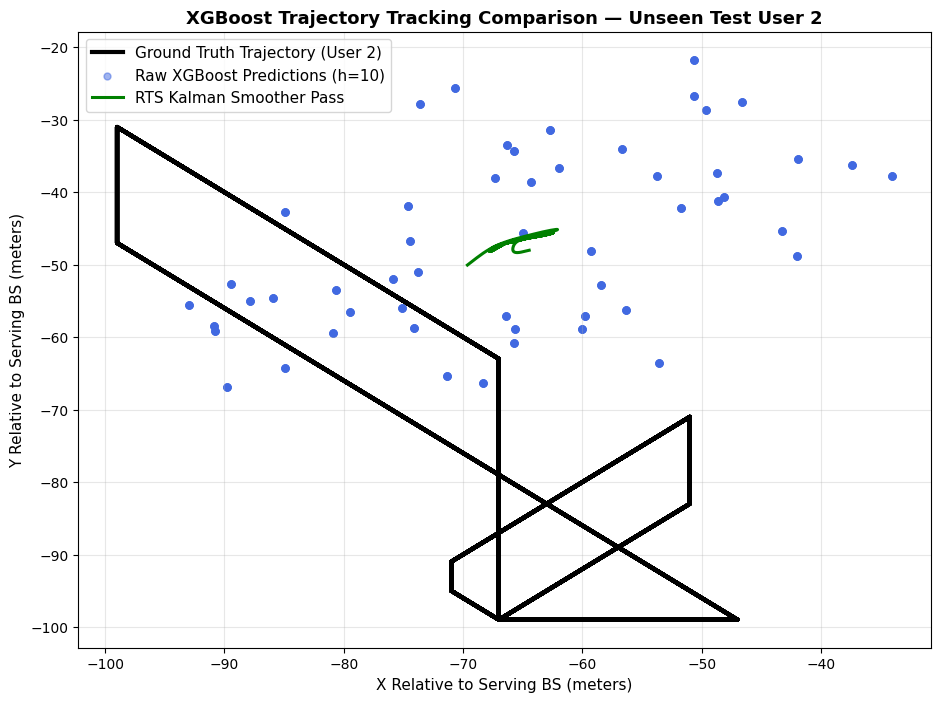

In [7]:
uid = sample_user_trajectories['uid']
gt  = sample_user_trajectories['gt']
raw = sample_user_trajectories['raw']
rts = sample_user_trajectories['rts']

plt.figure(figsize=(11, 8))
plt.plot(gt[:, 0], gt[:, 1], 'k-', lw=3.0, label=f'Ground Truth Trajectory (User {uid})')
plt.scatter(raw[:, 0], raw[:, 1], color='royalblue', alpha=0.5, s=25, label='Raw XGBoost Predictions (h=10)')
plt.plot(rts[:, 0], rts[:, 1], 'g-', lw=2.2, label='RTS Kalman Smoother Pass')
plt.xlabel('X Relative to Serving BS (meters)', fontsize=11)
plt.ylabel('Y Relative to Serving BS (meters)', fontsize=11)
plt.title(f'XGBoost Trajectory Tracking Comparison — Unseen Test User {uid}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / 'xgb_trajectory_tracking.png', dpi=150, bbox_inches='tight')
plt.show()